## 2024 Reinforcement Learning @ KHU

Soft Actor-Critic (SAC) — continuous-action CarRacing-v2
---

In [ ]:
import os, sys

# Colab-specific Google Drive mounting is not needed when running locally.
# This assumes the notebook is opened from its own project folder, so relative
# paths (checkpoints, videos, etc.) are created next to this .ipynb file.
print("Current working directory:", os.getcwd())

sys.path.append('..')  # add project root to the python path

Car Racing

https://gymnasium.farama.org/environments/box2d/car_racing/


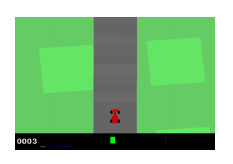

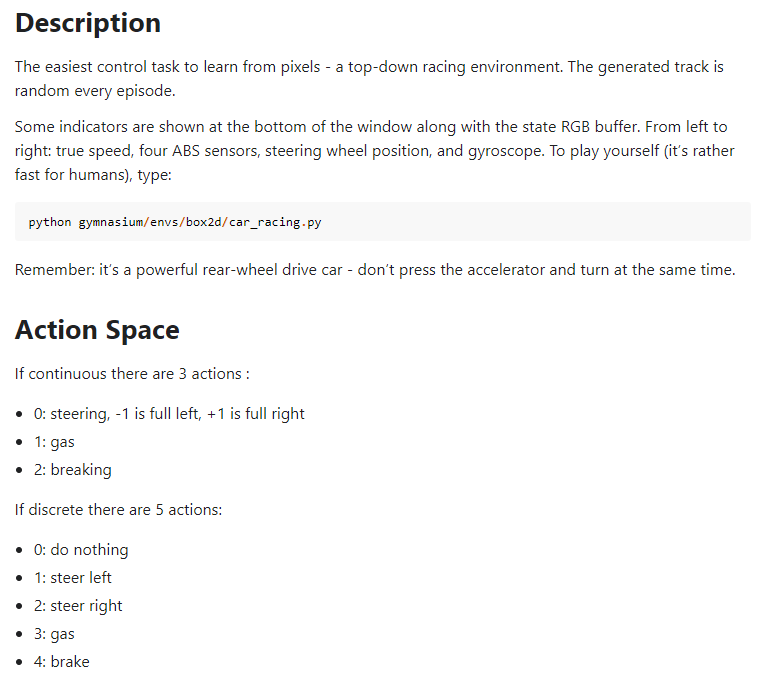

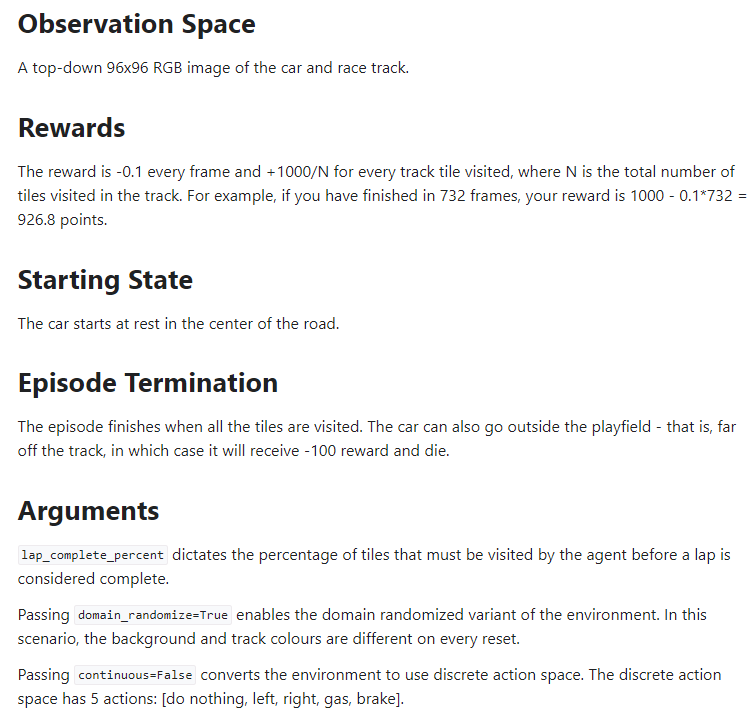

In [ ]:
# NOTE: run these once in a terminal (not every time you open the notebook):
#   pip install swig
#   pip install gymnasium
#   pip install "gymnasium[box2d]"
#   pip install opencv-python matplotlib torch
# On Windows, if "gymnasium[box2d]" fails to build, install "Microsoft C++ Build Tools"
# first, or try: conda install -c conda-forge box2d-py

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.animation as animation
from IPython.display import HTML
from IPython.display import clear_output

In [ ]:
env = gym.make('CarRacing-v2', continuous=True)
print("Observation space: ", env.observation_space)
print("Action space: ", env.action_space)  # Box([-1, 0, 0], [1, 1, 1]) -> [steer, gas, brake]

## Check the Video

# Preprocess the Image

In [ ]:
# Every frme always contains a black area at the bottom of the frame, so we had better cut this black area.
# Also, Color imformation is not directly related to car racing. So we will use gray image for computation efficiency.
# 학습에 불필요한 부분은 CROP 후에 사용함 (Grayscale로 변환)
def preprocess(img):
    img = img[:84, 6:90] # CarRacing-v2-specific cropping

    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) / 255.0
    return img

# Manual Environment

In [ ]:
class ImageEnv(gym.Wrapper):
    def __init__(
        self,
        env,
        skip_frames=4,
        stack_frames=4,
        initial_no_op=50,
        **kwargs
    ):
        super(ImageEnv, self).__init__(env, **kwargs)
        self.initial_no_op = initial_no_op
        self.skip_frames = skip_frames
        self.stack_frames = stack_frames

        # SAC uses the continuous action space (Box), while the earlier discrete
        # agents used action `0` as a no-op. Build a no-op action that works for both.
        if isinstance(env.action_space, gym.spaces.Box):
            self.no_op_action = np.zeros(env.action_space.shape, dtype=np.float32)
        else:
            self.no_op_action = 0

    def reset(self):
        # Reset the original environment.
        s, info = self.env.reset()

        # Do nothing for the next `self.initial_no_op` steps
        for i in range(self.initial_no_op):
            s, r, terminated, truncated, info = self.env.step(self.no_op_action)

        # Convert a frame to 84 X 84 gray scale one
        s = preprocess(s)

        # The initial observation is simply a copy of the frame `s`
        self.stacked_state = np.tile(s, (self.stack_frames, 1, 1))  # [4, 84, 84]
        return self.stacked_state, info

    def step(self, action):
        # We take an action for self.skip_frames steps
        # terminated: 완료 / truncated: 실패
        reward = 0
        for _ in range(self.skip_frames):
            s, r, terminated, truncated, info = self.env.step(action)
            reward += r
            if terminated or truncated:
                break

        # Convert a frame to 84 X 84 gray scale one
        s = preprocess(s)

        # Push the current frame `s` at the end of self.stacked_state
        self.stacked_state = np.concatenate((self.stacked_state[1:], s[np.newaxis]), axis=0)

        return self.stacked_state, reward, terminated, truncated, info

# Network

### ouput tensor size of Convolution layer

- $O$ : Size(width) of output image
- $I$: Size(width) of input image
- $K$: Size(width) of kernels used in the Conv layer
- $N$: Number of kernels
- $S$: Stride of the convolution operation
- $P$: Padding size

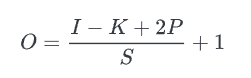

# Soft Actor-Critic (SAC)

[T. Haarnoja et al., "Soft Actor-Critic: Off-Policy Maximum Entropy Deep Reinforcement Learning with a Stochastic Actor." ICML, 2018.](https://arxiv.org/abs/1801.01290)

CarRacing-v2의 원래 행동 공간은 `[steer, gas, brake]` 3차원 연속값입니다. DQN이나 지금까지의 Actor-Critic 초안은 행동을 이산화해서 다뤄습니다만, SAC는 연속 행동을 그대로 다룰 수 있는 off-policy 알고리즘이라 이 환경에 훨씬 자연스럽게 맞습니다.

SAC의 핵심 아이디어:

- **Maximum entropy RL**: 보상뿐 아니라 정책의 엔트로피(무작위성)도 함께 최대화 → 탐험이 더 잘 되고, 여러 개의 좋은 행동이 있을 때 한쪽으로 조기 수렴하지 않음
- **Twin Q-network**: Critic을 2개(Q1, Q2) 두고 더 작은 값을 타겟으로 사용 → Q값 과대추정 방지
- **Reparameterization trick**: 정책이 `tanh(mean + std * noise)` 형태로 행동을 샘플링 → 그래디언트가 샘플링 과정을 통과해서 흘를 수 있음
- **자동 온도(α) 조절**: 엔트로피 보상의 가중치 α를 목표 엔트로피(target entropy)에 맞춰 자동으로 학습

In [ ]:
LOG_STD_MIN, LOG_STD_MAX = -20, 2

# Bounds of CarRacing-v2's continuous action space: [steer, gas, brake]
ACTION_LOW = np.array([-1.0, 0.0, 0.0], dtype=np.float32)
ACTION_HIGH = np.array([1.0, 1.0, 1.0], dtype=np.float32)


def rescale_action(tanh_action):
    """Map a tanh-squashed action in [-1, 1]^3 to CarRacing's actual action bounds."""
    return ACTION_LOW + (tanh_action + 1.0) * 0.5 * (ACTION_HIGH - ACTION_LOW)


class CNNEncoder(nn.Module):
    """Shared conv trunk that turns a stacked-frame image into a feature vector."""

    def __init__(self, in_channels):
        super(CNNEncoder, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=8, stride=4)  # [N, 4, 84, 84] -> [N, 16, 20, 20]
        self.conv2 = nn.Conv2d(16, 32, kernel_size=4, stride=2)  # [N, 16, 20, 20] -> [N, 32, 9, 9]
        self.out_features = 32 * 9 * 9

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        return x.view(x.size(0), -1)


class GaussianPolicy(nn.Module):
    """Actor: outputs a squashed Gaussian policy over the continuous action space."""

    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super(GaussianPolicy, self).__init__()
        self.encoder = CNNEncoder(state_dim[0])
        self.fc1 = nn.Linear(self.encoder.out_features, hidden_dim)
        self.mean = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = self.encoder(x)
        x = F.relu(self.fc1(x))
        mean = self.mean(x)
        log_std = torch.clamp(self.log_std(x), LOG_STD_MIN, LOG_STD_MAX)
        return mean, log_std

    def sample(self, x):
        mean, log_std = self.forward(x)
        std = log_std.exp()
        normal = torch.distributions.Normal(mean, std)

        z = normal.rsample()  # reparameterization trick: mean + std * N(0, 1)
        action = torch.tanh(z)

        # Correction term for the tanh squashing (SAC paper, appendix C)
        log_prob = normal.log_prob(z) - torch.log(1 - action.pow(2) + 1e-6)
        log_prob = log_prob.sum(dim=1, keepdim=True)

        mean_action = torch.tanh(mean)  # deterministic action, used for evaluation
        return action, log_prob, mean_action


class QNetwork(nn.Module):
    """Critic: estimates Q(s, a) for a continuous action a."""

    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super(QNetwork, self).__init__()
        self.encoder = CNNEncoder(state_dim[0])
        self.fc1 = nn.Linear(self.encoder.out_features + action_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x, a):
        x = self.encoder(x)
        x = torch.cat([x, a], dim=1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Replay Buffer

SAC는 off-policy 알고리즘이라 replay buffer와 자연스럽게 맞습니다. 이전 버전과 다른 점은 행동(action)이 이산 정수가 아니라 3차원 연속 벡터라는 것뿐입니다. 버퍼에는 정책이 실제로 믐은 `tanh` 스케일(`[-1, 1]`)의 행동을 저장하고, 환경에 넣기 직전에만 `rescale_action`으로 실제 범위로 변환합니다.

In [ ]:
class ReplayBuffer:
    def __init__(self, state_dim, action_dim, max_size=int(1e5)):
        self.s = np.zeros((max_size, *state_dim), dtype=np.float32)
        self.a = np.zeros((max_size, action_dim), dtype=np.float32)
        self.r = np.zeros((max_size, 1), dtype=np.float32)
        self.ns = np.zeros((max_size, *state_dim), dtype=np.float32)
        self.done = np.zeros((max_size, 1), dtype=np.float32)

        self.ptr = 0
        self.size = 0
        self.max_size = max_size

    def update(self, s, a, r, ns, done):
        self.s[self.ptr] = s
        self.a[self.ptr] = a
        self.r[self.ptr] = r
        self.ns[self.ptr] = ns
        self.done[self.ptr] = done

        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size):
        ind = np.random.randint(0, self.size, batch_size)
        return (
            torch.FloatTensor(self.s[ind]),
            torch.FloatTensor(self.a[ind]),
            torch.FloatTensor(self.r[ind]),
            torch.FloatTensor(self.ns[ind]),
            torch.FloatTensor(self.done[ind]),
        )

# SAC Agent

- **Critic 업데이트**: 타겟 `y = r + γ(1-done)·(min(Q1_targ, Q2_targ)(s', a') - α·log π(a'|s'))`을 향해 두 Q-network를 각각 MSE로 학습
- **Actor 업데이트**: `J(π) = E[α·log π(a|s) - min(Q1, Q2)(s, a)]`를 최소화 (= expected Q값은 최대화하면서 엔트로피도 함께 최대화)
- **α(온도) 업데이트**: 목표 엔트로피(`-action_dim`)에 맞춰 `log α`를 자동으로 학습
- **타겟 네트워크**: hard update 대신 매 스텝 `τ`(예: 0.005)만큼만 반영하는 soft update(polyak averaging) 사용 → 이전 Actor-Critic 초안보다 훨씬 안정적

In [ ]:
class SAC:
    def __init__(
        self,
        state_dim,
        action_dim,
        lr=3e-4,
        gamma=0.99,
        tau=0.005,
        batch_size=256,
        warmup_steps=1000,
        buffer_size=int(1e5),
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size
        self.warmup_steps = warmup_steps
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        self.actor = GaussianPolicy(state_dim, action_dim).to(self.device)

        self.critic1 = QNetwork(state_dim, action_dim).to(self.device)
        self.critic2 = QNetwork(state_dim, action_dim).to(self.device)
        self.critic1_target = QNetwork(state_dim, action_dim).to(self.device)
        self.critic2_target = QNetwork(state_dim, action_dim).to(self.device)
        self.critic1_target.load_state_dict(self.critic1.state_dict())
        self.critic2_target.load_state_dict(self.critic2.state_dict())
        for p in self.critic1_target.parameters():
            p.requires_grad_(False)
        for p in self.critic2_target.parameters():
            p.requires_grad_(False)

        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr)
        self.critic1_optimizer = torch.optim.Adam(self.critic1.parameters(), lr)
        self.critic2_optimizer = torch.optim.Adam(self.critic2.parameters(), lr)

        # Automatic entropy temperature (alpha) tuning
        self.target_entropy = -float(action_dim)
        self.log_alpha = torch.zeros(1, requires_grad=True, device=self.device)
        self.alpha_optimizer = torch.optim.Adam([self.log_alpha], lr)

        self.replay_buffer = ReplayBuffer(state_dim, action_dim, buffer_size)
        self.total_steps = 0

    @property
    def alpha(self):
        return self.log_alpha.exp()

    def select_action(self, state, training=True):
        # Pure-random exploration during warmup, so the replay buffer fills with
        # diverse transitions before the (still untrained) policy starts driving.
        if training and self.total_steps < self.warmup_steps:
            return np.random.uniform(-1.0, 1.0, size=self.action_dim).astype(np.float32)

        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            action, _, mean_action = self.actor.sample(state)
        chosen = action if training else mean_action
        return chosen.cpu().numpy()[0]

    def update_model(self):
        s, a, r, ns, done = map(lambda x: x.to(self.device), self.replay_buffer.sample(self.batch_size))

        # ---- Critic update ----
        with torch.no_grad():
            next_action, next_log_prob, _ = self.actor.sample(ns)
            target_q1 = self.critic1_target(ns, next_action)
            target_q2 = self.critic2_target(ns, next_action)
            target_q = torch.min(target_q1, target_q2) - self.alpha * next_log_prob
            target_value = r + (1 - done) * self.gamma * target_q

        critic1_loss = F.mse_loss(self.critic1(s, a), target_value)
        self.critic1_optimizer.zero_grad()
        critic1_loss.backward()
        self.critic1_optimizer.step()

        critic2_loss = F.mse_loss(self.critic2(s, a), target_value)
        self.critic2_optimizer.zero_grad()
        critic2_loss.backward()
        self.critic2_optimizer.step()

        # ---- Actor update ----
        new_action, log_prob, _ = self.actor.sample(s)
        q_new = torch.min(self.critic1(s, new_action), self.critic2(s, new_action))
        actor_loss = (self.alpha.detach() * log_prob - q_new).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # ---- Temperature (alpha) update ----
        alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
        self.alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.alpha_optimizer.step()

        # ---- Soft-update target critics ----
        with torch.no_grad():
            for target_param, param in zip(self.critic1_target.parameters(), self.critic1.parameters()):
                target_param.data.mul_(1 - self.tau).add_(self.tau * param.data)
            for target_param, param in zip(self.critic2_target.parameters(), self.critic2.parameters()):
                target_param.data.mul_(1 - self.tau).add_(self.tau * param.data)

    def process(self, transition):
        self.total_steps += 1
        self.replay_buffer.update(*transition)
        if self.replay_buffer.size >= self.batch_size and self.total_steps > self.warmup_steps:
            self.update_model()

# Training

In [ ]:
env = gym.make('CarRacing-v2', continuous=True, render_mode='rgb_array')
env = ImageEnv(env)

max_steps = int(200000)
eval_interval = 2000
state_dim = (4, 84, 84)
action_dim = env.action_space.shape[0]  # [steer, gas, brake]

agent = SAC(state_dim, action_dim)

In [ ]:
def evaluate(agent, n_evals=3):
    eval_env = gym.make('CarRacing-v2', continuous=True, render_mode='rgb_array')
    eval_env = ImageEnv(eval_env)

    total_rewards = 0.0
    for _ in range(n_evals):
        s, _ = eval_env.reset()
        done = False
        truncated = False
        while not done and not truncated:
            a = agent.select_action(s, training=False)
            s, r, done, truncated, _ = eval_env.step(rescale_action(a))
            total_rewards += r
    eval_env.close()
    return total_rewards / n_evals

Training!!

In [ ]:
history = {'Step': [], 'AvgReturn': []}
s, _ = env.reset()

while agent.total_steps < max_steps:
    a = agent.select_action(s)
    ns, r, terminated, truncated, _ = env.step(rescale_action(a))

    # Store the raw tanh-scale action (not the rescaled env action) in the buffer,
    # since that's what the policy's log-prob math is defined over.
    agent.process((s, a, r, ns, terminated))
    s = ns

    if terminated or truncated:
        s, _ = env.reset()

    if agent.total_steps % eval_interval == 0:
        rewards = evaluate(agent)
        history['Step'].append(agent.total_steps)
        history['AvgReturn'].append(rewards)

        clear_output()
        plt.figure(figsize=(8, 5))
        plt.plot(history['Step'], history['AvgReturn'], 'r-')
        plt.xlabel('Step', fontsize=16)
        plt.ylabel('AvgReturn', fontsize=16)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.grid(axis='y')
        plt.show()

        torch.save(agent.actor.state_dict(), 'sac_actor.pt')
        torch.save(agent.critic1.state_dict(), 'sac_critic1.pt')
        torch.save(agent.critic2.state_dict(), 'sac_critic2.pt')
        torch.save(agent.log_alpha, 'sac_log_alpha.pt')

# Visualize

In [ ]:
import glob
import base64, io

In [ ]:
def show_video_of_model(agent, env_name):
    eval_env = gym.make(env_name, continuous=True, render_mode='rgb_array')
    eval_env = ImageEnv(eval_env)

    agent.actor.load_state_dict(torch.load('sac_actor.pt', map_location=agent.device))

    state, _ = eval_env.reset()
    done = False
    truncated = False

    frames = []
    while not done and not truncated:
        frames.append(eval_env.render())
        action = agent.select_action(state, training=False)  # deterministic (mean) action
        state, reward, done, truncated, _ = eval_env.step(rescale_action(action))

    eval_env.close()

    fig = plt.figure(figsize=(5, 5))
    plt.axis('off')
    im = plt.imshow(frames[0])

    def animate(i):
        im.set_array(frames[i])
        return im,

    anim = animation.FuncAnimation(fig, animate, frames=len(frames))
    anim.save("CarRacing-v2-SAC.mp4")
    plt.close(fig)


show_video_of_model(agent, 'CarRacing-v2')


def show_video():
    mp4list = glob.glob('*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display(HTML(data='''<video alt="test" autoplay loop controls style="height: 400px;">
                                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
                             </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")


show_video()